# 08. Hotspot Analysis

## Objective

Identify the major taxi pickup hotspots across the service area and compare
pickup demand between AM and PM periods.

The analysis uses the zone-level statistics and AM/PM hotspot results generated
during the taxi-zone aggregation stage. This avoids repeatedly processing the
full raw taxi dataset while preserving the aggregated results required for
spatial interpretation.

### Key questions

1. Which taxi zones have the highest pickup demand?
2. Which zones are dominant during AM and PM periods?
3. How does demand change between AM and PM?
4. What operational insights can be derived from these patterns?

In [4]:
# Locate the existing hotspot outputs without reprocessing the raw taxi data.

from pathlib import Path

BASE_DIR = Path(r"C:\Users\arudk\Downloads\UrbanFlow_AI")

files_to_find = [
    "pickup_zone_statistics.csv",
    "dropoff_zone_statistics.csv",
    "od_flow_statistics.csv",
    "am_pm_hotspots.csv",
    "hourly_demand.parquet"
]

print("Searching project directory...\n")

for filename in files_to_find:
    matches = list(BASE_DIR.rglob(filename))

    if matches:
        print(f"FOUND: {filename}")
        for path in matches:
            print(f"  {path}")
    else:
        print(f"NOT FOUND: {filename}")

Searching project directory...

FOUND: pickup_zone_statistics.csv
  C:\Users\arudk\Downloads\UrbanFlow_AI\data\processed\taxi_zone\pickup_zone_statistics.csv
FOUND: dropoff_zone_statistics.csv
  C:\Users\arudk\Downloads\UrbanFlow_AI\data\processed\taxi_zone\dropoff_zone_statistics.csv
FOUND: od_flow_statistics.csv
  C:\Users\arudk\Downloads\UrbanFlow_AI\data\processed\taxi_zone\od_flow_statistics.csv
FOUND: am_pm_hotspots.csv
  C:\Users\arudk\Downloads\UrbanFlow_AI\data\processed\taxi_zone\am_pm_hotspots.csv
FOUND: hourly_demand.parquet
  C:\Users\arudk\Downloads\UrbanFlow_AI\data\processed\taxi_zone\hourly_demand.parquet


In [6]:
# Load the aggregated zone-level results produced by Notebook 06.
# These files contain the information needed for hotspot analysis.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\arudk\Downloads\UrbanFlow_AI")
ZONE_OUTPUT_DIR = BASE_DIR / "data" / "processed" / "taxi_zone"
FIGURE_DIR = BASE_DIR / "reports" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pickup_stats = pd.read_csv(
    ZONE_OUTPUT_DIR / "pickup_zone_statistics.csv"
)

am_pm_hotspots = pd.read_csv(
    ZONE_OUTPUT_DIR / "am_pm_hotspots.csv"
)

print("Pickup statistics shape:", pickup_stats.shape)
print("AM/PM hotspot shape:", am_pm_hotspots.shape)

print("\nPickup statistics:")
display(pickup_stats.head())

print("\nAM/PM hotspot results:")
display(am_pm_hotspots.head())

Pickup statistics shape: (262, 4)
AM/PM hotspot shape: (262, 5)

Pickup statistics:


,loc_id,pickup_trip_count,borough_name,zone_name
0,237,2113429,Manhattan,Upper East Side South
1,161,2023458,Manhattan,Midtown Center
2,236,1867732,Manhattan,Upper East Side North
3,132,2059989,Queens,JFK Airport
4,162,1477633,Manhattan,Midtown East



AM/PM hotspot results:


,loc_id,am_trip_count,pm_trip_count,borough_name,zone_name
0,1,1242,3333,EWR,Newark Airport
1,2,20,23,Queens,Jamaica Bay
2,3,2209,1335,Bronx,Allerton/Pelham Gardens
3,4,38400,31999,Manhattan,Alphabet City
4,5,3,7,Staten Island,Arden Heights


## 1. Major Pickup Hotspots

Pickup hotspots are identified by ranking taxi zones according to their
total pickup trip count over the study period.

The ranking helps identify locations with consistently high taxi demand
and provides a basis for comparing spatial demand patterns.

In [9]:
# Rank zones by total pickup demand.
# Sorting is performed explicitly so the ranking is independent of the
# original order of the aggregated file.

top_pickup_zones = (
    pickup_stats
    .sort_values("pickup_trip_count", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top 15 pickup hotspots:")
display(top_pickup_zones)

Top 15 pickup hotspots:


,loc_id,pickup_trip_count,borough_name,zone_name
0,237,2113429,Manhattan,Upper East Side South
1,132,2059989,Queens,JFK Airport
2,161,2023458,Manhattan,Midtown Center
3,236,1867732,Manhattan,Upper East Side North
4,186,1508078,Manhattan,Penn Station/Madison Sq West
5,162,1477633,Manhattan,Midtown East
6,230,1450984,Manhattan,Times Sq/Theatre District
7,142,1371620,Manhattan,Lincoln Square East
8,170,1273860,Manhattan,Murray Hill
9,234,1268407,Manhattan,Union Sq


### Interpretation

The highest-demand pickup locations are concentrated primarily in
Manhattan, with major activity around the Upper East Side, Midtown,
Penn Station, Times Square, and Union Square. Airport zones such as JFK
and LaGuardia also represent important high-volume pickup locations.

These hotspots indicate areas where taxi supply allocation and demand
management can have a particularly strong operational impact.

## 2. Top Pickup Hotspots

The following visualization shows the 15 zones with the highest total
pickup demand during the study period.

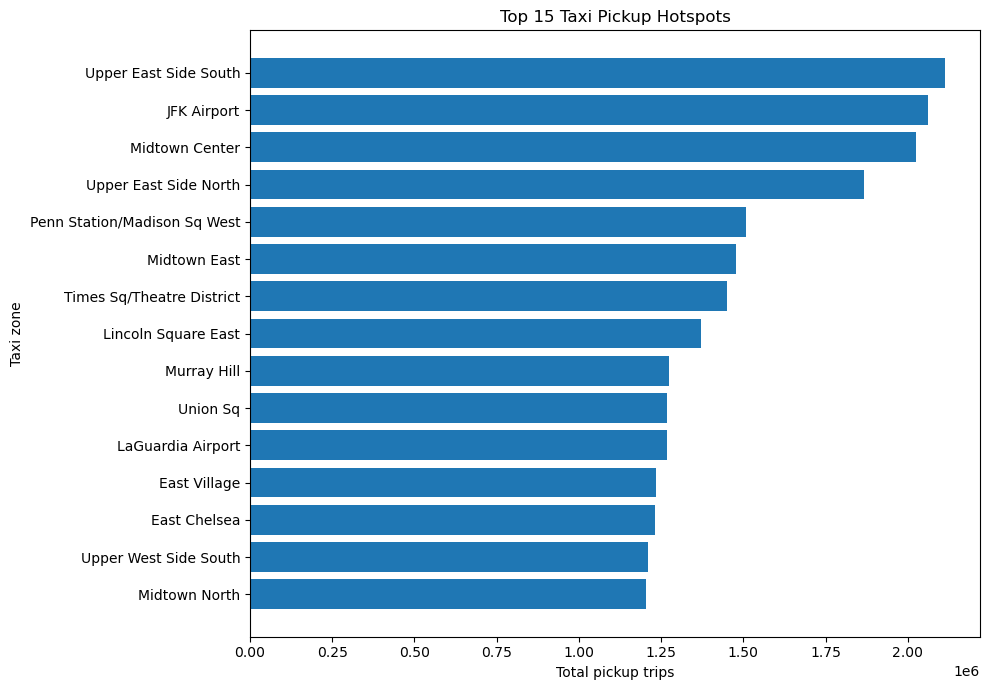

Figure saved: C:\Users\arudk\Downloads\UrbanFlow_AI\reports\figures\top_15_pickup_hotspots.png


In [13]:
# Visualize the highest-demand pickup zones.

plot_data = top_pickup_zones.sort_values(
    "pickup_trip_count",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["zone_name"],
    plot_data["pickup_trip_count"]
)

plt.xlabel("Total pickup trips")
plt.ylabel("Taxi zone")
plt.title("Top 15 Taxi Pickup Hotspots")

plt.tight_layout()

hotspot_path = FIGURE_DIR / "top_15_pickup_hotspots.png"
plt.savefig(hotspot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved: {hotspot_path}")

## 3. AM vs PM Hotspot Comparison

To understand how taxi demand changes throughout the day, pickup activity is
compared between AM and PM periods for each taxi zone.

The PM-to-AM demand ratio is calculated to identify zones where evening demand
is substantially stronger than morning demand.

In [16]:
# Calculate the PM-to-AM demand ratio and absolute change.
# A small epsilon prevents division by zero for zones with no AM pickups.

am_pm_analysis = am_pm_hotspots.copy()

am_pm_analysis["pm_minus_am"] = (
    am_pm_analysis["pm_trip_count"]
    - am_pm_analysis["am_trip_count"]
)

am_pm_analysis["pm_am_ratio"] = (
    am_pm_analysis["pm_trip_count"]
    / am_pm_analysis["am_trip_count"].replace(0, np.nan)
)

am_pm_analysis["pm_increase_pct"] = (
    (am_pm_analysis["pm_trip_count"] - am_pm_analysis["am_trip_count"])
    / am_pm_analysis["am_trip_count"].replace(0, np.nan)
) * 100

# Rank by PM demand for reporting.
top_pm_zones = (
    am_pm_analysis
    .sort_values("pm_trip_count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 PM pickup hotspots:")
display(
    top_pm_zones[
        [
            "loc_id",
            "zone_name",
            "borough_name",
            "am_trip_count",
            "pm_trip_count",
            "pm_minus_am",
            "pm_am_ratio",
            "pm_increase_pct"
        ]
    ]
)

Top 10 PM pickup hotspots:


,loc_id,zone_name,borough_name,am_trip_count,pm_trip_count,pm_minus_am,pm_am_ratio,pm_increase_pct
0,237,Upper East Side South,Manhattan,471141,933326,462185,1.980991,98.099083
1,236,Upper East Side North,Manhattan,546086,835406,289320,1.529807,52.980666
2,161,Midtown Center,Manhattan,315919,804979,489060,2.548055,154.805504
3,132,JFK Airport,Queens,318219,718535,400316,2.257989,125.798900
4,162,Midtown East,Manhattan,323452,551897,228445,1.706272,70.627172
5,186,Penn Station/Madison Sq West,Manhattan,398321,504959,106638,1.267719,26.771875
6,138,LaGuardia Airport,Queens,238671,500901,262230,2.098709,109.870910
7,239,Upper West Side South,Manhattan,308150,491634,183484,1.595437,59.543729
8,142,Lincoln Square East,Manhattan,280152,489304,209152,1.746566,74.656615
9,170,Murray Hill,Manhattan,287499,472451,184952,1.643314,64.331354


## 4. AM vs PM Demand at Major Hotspots

The AM and PM pickup volumes are compared for the ten highest-demand PM
hotspots. This highlights locations where taxi demand shifts substantially
towards the PM period.

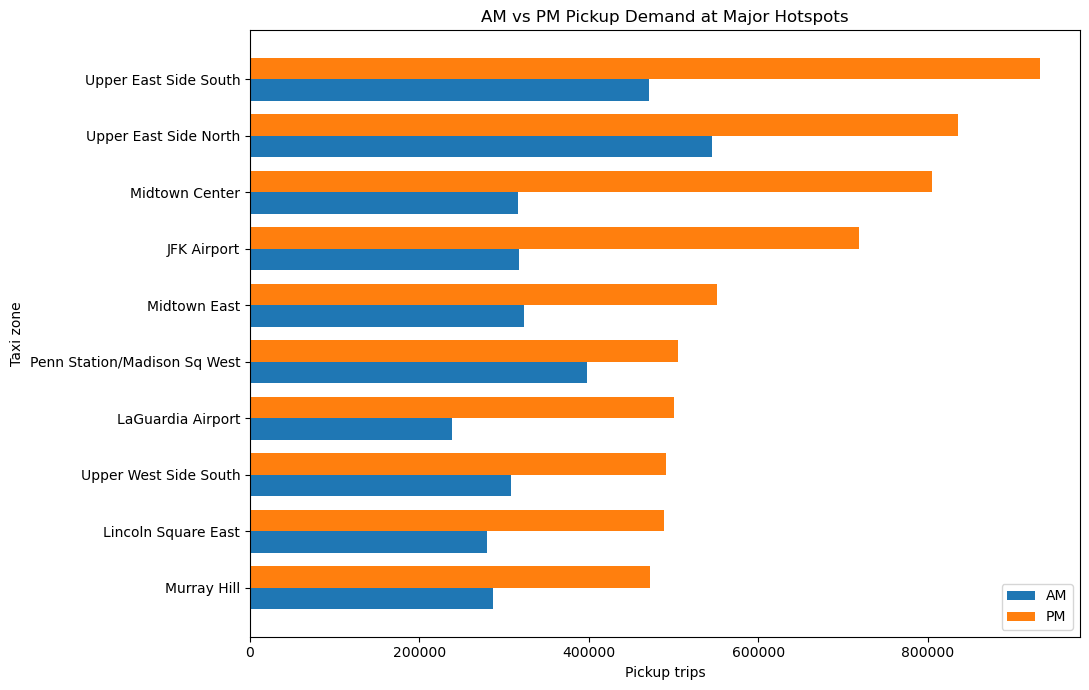

Figure saved: C:\Users\arudk\Downloads\UrbanFlow_AI\reports\figures\am_vs_pm_hotspots.png


In [19]:
# Compare AM and PM pickup demand across the major hotspots.

plot_data = top_pm_zones.sort_values(
    "pm_trip_count",
    ascending=True
)

y = np.arange(len(plot_data))
bar_height = 0.38

plt.figure(figsize=(11, 7))

plt.barh(
    y - bar_height / 2,
    plot_data["am_trip_count"],
    height=bar_height,
    label="AM"
)

plt.barh(
    y + bar_height / 2,
    plot_data["pm_trip_count"],
    height=bar_height,
    label="PM"
)

plt.yticks(
    y,
    plot_data["zone_name"]
)

plt.xlabel("Pickup trips")
plt.ylabel("Taxi zone")
plt.title("AM vs PM Pickup Demand at Major Hotspots")
plt.legend()

plt.tight_layout()

am_pm_path = FIGURE_DIR / "am_vs_pm_hotspots.png"
plt.savefig(am_pm_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved: {am_pm_path}")

## 5. Key AM vs PM Findings

The AM/PM comparison shows a clear shift towards higher PM pickup activity
across the major taxi hotspots.

The PM-to-AM ratio and absolute increase are used together to distinguish
zones with both high demand and substantial evening growth.

In [22]:
# Identify the strongest PM shifts among the major hotspots.
# Absolute increase shows the volume change, while the ratio shows
# how strongly PM demand exceeds AM demand.

strongest_pm_shift = (
    am_pm_analysis[
        am_pm_analysis["am_trip_count"] > 0
    ]
    .sort_values("pm_am_ratio", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Zones with the strongest PM-to-AM demand ratios:")

display(
    strongest_pm_shift[
        [
            "loc_id",
            "zone_name",
            "borough_name",
            "am_trip_count",
            "pm_trip_count",
            "pm_minus_am",
            "pm_am_ratio",
            "pm_increase_pct"
        ]
    ]
)

# Save the enriched AM/PM analysis for reporting.
am_pm_output_path = OUTPUT_DIR / "am_pm_hotspot_analysis.csv"

am_pm_analysis.to_csv(
    am_pm_output_path,
    index=False
)

print(f"\nAM/PM analysis saved:")
print(am_pm_output_path)

Zones with the strongest PM-to-AM demand ratios:


,loc_id,zone_name,borough_name,am_trip_count,pm_trip_count,pm_minus_am,pm_am_ratio,pm_increase_pct
0,105,Governor's Island/Ellis Island/Liberty Island,Manhattan,1,6,5,6.000000,500.000000
1,12,Battery Park,Manhattan,2036,11477,9441,5.637033,463.703340
2,199,Rikers Island,Bronx,2,8,6,4.000000,300.000000
3,93,Flushing Meadows-Corona Park,Queens,1329,5241,3912,3.943567,294.356659
4,144,Little Italy/NoLiTa,Manhattan,43243,165328,122085,3.823232,282.323151
5,211,SoHo,Manhattan,40209,145632,105423,3.621876,262.187570
6,88,Financial District South,Manhattan,21255,67115,45860,3.157610,215.760997
7,246,West Chelsea/Hudson Yards,Manhattan,111898,341915,230017,3.055595,205.559527
8,34,Brooklyn Navy Yard,Brooklyn,779,2349,1570,3.015404,201.540436
9,261,World Trade Center,Manhattan,38994,110034,71040,2.821819,182.181874



AM/PM analysis saved:
C:\Users\arudk\Downloads\UrbanFlow_AI\outputs\am_pm_hotspot_analysis.csv
